# Portfolio 3 - Multi-Agent Reinforcement Learning (Atari Warlords)

Vak: Autonomous Systems · De Haagse Hogeschool

Dit notebook vormt zowel het rapport als de reproduceerbare pijplijn. Wij trainen een Deep RL-agent die in de multi-agent Atari-omgeving Warlords concurreert met drie andere agenten, en wij vergelijken deze met twee baselines. De eindoplevering bestaat uit per-hoek getrainde independent PPO-policies (IPPO) en, ter vergelijking, een hoek-robuust league-beleid (random -> rule-based -> self-play).

> Uitvoeren: dit notebook draait lokaal op Linux/WSL2 met een NVIDIA GPU, of in Google Colab (GPU-runtime). De Atari-backend `multi_agent_ale_py` heeft geen Windows-wheels; native Windows werkt niet. De totale rekentijd bedraagt bij volledige instellingen ongeveer 7–8 uur op een laptop-GPU (RTX 5050 / 20 CPU-cores); met de "snel"-instellingen ongeveer 30 minuten voor demonstratiedoeleinden.

| | |
|---|---|
| Project | Multi-Agent Reinforcement Learning |
| Omgeving | `pettingzoo.atari.warlords_v3` (RAM-observaties) |
| Algoritme | PPO (Proximal Policy Optimization) via Stable-Baselines3 |
| MARL-strategie | Independent PPO (IPPO) per hoek + hoek-robuust league-curriculum |
| Evaluatie | Win-rate tegen een random- en een rule-based baseline |

In dit project trainen wij een reinforcement-learning agent voor het Atari-spel Warlords. In dit spel verdedigen vier spelers elk hun eigen kasteel in een hoek.

Als basisalgoritme gebruiken wij PPO (Proximal Policy Optimization). Omdat alle vier de hoeken dezelfde globale RAM waarnemen, trainen wij independent learners: een afzonderlijk PPO-beleid per hoek, met per generatie bevroren tegenstanders.

Daarnaast onderzoeken wij een hoek-robuust beleid dat via een league-curriculum tegen steeds sterkere tegenstanders leert (random -> rule-based -> self-play).

Het doel van het project is een agent te ontwikkelen die aantoonbaar beter presteert dan een random- en een rule-based baseline, en uiteindelijk sterk genoeg is om mee te doen aan een toernooi met de hele klas.

## Inhoudsopgave

1. Inleiding & Probleemanalyse
   - 1.1 De omgeving: Warlords
   - 1.2 Waarom dit een multi-agent-probleem is
   - 1.3 Een cruciale observatie over de RAM
   - 1.4 Keuze van algoritme en trainingsstrategie
   - 1.5 Baseline
2. Setup
3. De omgeving verkennen
4. Baselines
5. Methode: van multi-agent naar trainbaar single-agent
6. Training (IPPO)
7. Resultaten & Discussie
   - 7.1 Leercurves
   - 7.2 RL vs. baseline
   - 7.4 Een wedstrijd opnemen
8. Hyperparameter-experimenten
   - 8.1 Learning rate
   - 8.2 Entropy-coëfficiënt
9. Toernooi-agent: hoek-robuust league
   - 9.1 Trainingsstrategie
   - 9.2 Reward shaping en hyperparameters
   - 9.3 League-curriculum training
   - 9.4 Leercurve van de league
   - 9.5 Toernooi-evaluatie
   - 9.7 Analyse: waarom het hoek-robuuste beleid faalt
   - 9.8 Klassentoernooi-test: corner-robust vs. henry's model
   - 9.8c Stochastische re-match
   - 9.9 IPPO per-hoek specialists vs. henry's model
   - 9.10 Definitieve matchup: IPPO vs. henry (400 games)
   - 9.11 Omgekeerde matchup: henry vs. 3× IPPO
10. Conclusie & Reflectie
12. Referentielijst

## 1. Inleiding & Probleemanalyse

Reinforcement Learning (RL) is een tak van machine learning waarin een agent leert door te handelen in een omgeving en daar feedback op te krijgen (Sutton & Barto, 2018). In de afgelopen jaren is RL sterk gegroeid dankzij de combinatie met diepe neurale netwerken (Deep RL). Bekende successen zijn AlphaGo (Silver et al., 2018) en OpenAI Five in Dota 2 (Berner et al., 2019). De meeste van deze successen spelen zich af in omgevingen met een agent of met vaste teams. Multi-Agent Reinforcement Learning (MARL), waarbij meerdere agenten tegelijk leren en elkaar beïnvloeden, is veel complexer, omdat de omgeving voor elke agent voortdurend verandert doordat de andere agenten ook leren (Li et al., 2025).

Dit portfolio-project gaat precies over dat probleem. Wij bouwen een agent voor het Atari-spel Warlords, dat beschikbaar is in de PettingZoo-bibliotheek (Terry et al., 2021). Warlords is een spel met vier spelers die elk een fort verdedigen. De beloning is eenvoudig: +1 bij winst, −1 bij verlies en 0 voor alle tussenliggende stappen. Deze late en schaarse beloning maakt het leren moeilijk. Daarnaast trainen wij via self-play: de agent speelt tegen eerdere versies van zichzelf, wat extra aandacht vraagt voor de stabiliteit van het leerproces (Berner et al., 2019).

### 1.1 De omgeving: Warlords
Warlords is een Atari-spel met vier spelers die elk een kasteel in een hoek verdedigen met een paddle. Een bal stuitert rond; wordt een kasteel geraakt, dan valt de betreffende speler af. De laatste speler die overblijft, wint. In de PettingZoo-implementatie (`warlords_v3`) betekent dit:

| Eigenschap | Waarde |
|---|---|
| Agenten | `first_0`, `second_0`, `third_0`, `fourth_0` (4) |
| Actieruimte | `Discrete(6)`: 0=noop, 1=fire, 2=up, 3=right, 4=left, 5=down |
| Observatie (`obs_type="ram"`) | 128 bytes console-RAM (`uint8`, 0–255) |
| Beloning | spaarzaam/terminaal: −1 wanneer het eigen kasteel valt, +1 wanneer de speler als laatste overblijft |

Dit is een competitieve, gemengde multi-agent-omgeving: de agenten delen een omgeving, maar hebben tegengestelde belangen.

### 1.2 Waarom dit een multi-agent-probleem is
Vanuit het perspectief van een agent vormen de andere drie agenten onderdeel van de omgeving. Omdat die anderen ook leren en hun gedrag veranderen, is de omgeving niet-stationair: de optimale strategie verschuift terwijl de tegenstanders beter worden (Busoniu et al., 2008; Lowe et al., 2017). Een goede aanpak moet hier expliciet rekening mee houden.

### 1.3 RAM
In `warlords_v3` ontvangen alle vier de agenten dezelfde globale 128-byte RAM (zie `base_atari_env.py`: `{agent: obs for agent in self.agents}`). Er is dus geen hoek-specifieke observatie en geen indicator van welke hoek een agent bestuurt. Een enkel gedeeld beleid kan de hoeken daardoor niet uit elkaar houden. Dit motiveert direct onze keuze voor independent learners: vier afzonderlijke policies, een per hoek, die elk hun eigen hoek leren verdedigen.

### 1.4 Keuze van algoritme en trainingsstrategie

Wij hebben een deep reinforcement learning-algoritme nodig dat een stochastisch beleid kan leren in een Atari-omgeving met discrete acties en meerdere agenten. De onderstaande families zetten de belangrijkste afwegingen op een rij:

| Familie | Voorbeeld | Voordelen | Nadelen voor ons |
|---|---|---|---|
| Waarde-gebaseerd | DQN, Double-DQN, Rainbow | sample-efficiënt, veel getest op Atari (Mnih et al., 2015) | off-policy met replay-buffer is lastig onder self-play; ε-greedy is zwak in competitief spel; geen stochastisch beleid |
| On-policy actor-critic | A2C / A3C (Mnih et al., 2016) | eenvoudig, stabiel | geen trust-region -> grote updates kunnen het beleid laten instorten bij ruis en schaarse beloning |
| Trust-region | TRPO (Schulman et al., 2015) | sterke theoretische garanties | tweede-orde; duur; lastig met parameter sharing |
| Clipped policy gradient | PPO (Schulman et al., 2017) | eerste-orde, eenvoudig, stochastisch beleid, goed op Atari en in multi-agent | gevoelig voor hyperparameters; vraagt zorg met beloningsschaal (Engstrom et al., 2020) |
| Off-policy actor-critic (continu) | SAC, DDPG, TD3 | sample-efficiënt | gemaakt voor continue acties; geen natuurlijke fit voor Atari |
| Model-based / planning | MuZero, Dreamer | erg sterk op Atari | veel complexer; overkill voor dit project |

Wij kiezen voor de volgende combinatie:

- Algoritme: PPO (Proximal Policy Optimization; Schulman et al., 2017). PPO is een on-policy actor-critic methode die door zijn clipped objective stabiel en robuust traint met weinig hyperparameter-tuning. Dat is een groot voordeel in een niet-stationaire multi-agent-setting, waar waarde-gebaseerde methoden (zoals DQN) gevoeliger zijn voor instabiliteit (de Witt et al., 2020).
- Trainingsstrategie: Independent PPO (IPPO) met generatie-gewijs bevroren tegenstanders. Elke hoek heeft een eigen PPO-beleid. Wij temmen de niet-stationariteit door de tegenstanders per generatie te bevriezen: elk beleid traint tegen vaste snapshots van de andere drie, waarna alle snapshots worden geüpdatet. Dit is verwant aan fictitious self-play (Heinrich & Silver, 2016) en aan IPPO (de Witt et al., 2020), dat verrassend sterk presteert in competitieve benchmarks.
- Observatie: RAM. Het toernooi gebruikt `obs_type="ram"`, en een kleine MLP op 128 bytes traint veel sneller dan een CNN op pixels - ideaal voor de vele benodigde environment-stappen.

PPO is on-policy en gebruikt een rollout-buffer in plaats van experience replay; de gradiënt-updates volgen het clipped surrogate objective (Schulman et al., 2017).

### 1.5 Baseline
Als referentie gebruiken wij twee baselines (opdracht 2a): een random policy en een rule-based policy die actief de eigen hoek patrouilleert en periodiek vuurt. Beide worden nader uitgewerkt in 4.

## 2. Setup

Lokaal (aanbevolen). Activeer een venv en installeer eenmalig de dependencies uit `requirements.txt`; download daarna de Atari-ROMs via `AutoROM --accept-license`. De volgende cel valideert dat alles aanwezig is en onderneemt geen actie wanneer dat het geval is.

Colab. Verwijder het commentaar voor de pip-install-regel in 2.1 en herstart vervolgens de kernel (Runtime -> Restart) alvorens verder te gaan.

In [1]:
# 2.1 Setup-check. Lokaal: zorg dat je `.venv` is geactiveerd. Colab: uncomment de pip-regel.
# !pip -q install "pettingzoo[atari]>=1.24" "autorom[accept-rom-license]" "stable-baselines3>=2.0.0" imageio imageio-ffmpeg tqdm rich
# !AutoROM --accept-license

import importlib, sys
missing = [m for m in ("pettingzoo", "stable_baselines3", "torch", "imageio", "pandas")
           if importlib.util.find_spec(m) is None]
if missing:
    print("Ontbrekend:", missing,
          "\nLokaal: `pip install -r Portfolio3/requirements.txt` in je venv.")
else:
    import torch
    print(f"OK · Python {sys.version.split()[0]} · torch {torch.__version__} · CUDA {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")

OK · Python 3.12.3 · torch 2.12.1+cu130 · CUDA True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [ ]:
# 2.2 Zet werkmap op Portfolio3/ zodat alle paden kloppen.
import os, sys
if os.path.basename(os.getcwd()) != "Portfolio3":
    for cand in ["Portfolio3", "adsai-autonomous-systems/Portfolio3"]:
        if os.path.isdir(os.path.join(cand, "warlords_marl")):
            os.chdir(cand); break
sys.path.insert(0, os.getcwd())
assert os.path.isdir("warlords_marl"), "Map 'warlords_marl' niet gevonden in werkmap."
print("Werkmap:", os.getcwd())

Werkmap: /home/michal-ubuntu/adsai-autonomous-systems/Portfolio3


In [ ]:
# 2.3 Imports
import os, multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import torch

from warlords_marl import AGENT_ORDER, ACTION_MEANINGS
from warlords_marl.env_wrapper import make_parallel_env
from warlords_marl.baselines import RandomPolicy, RuleBasedPolicy, PolicyOpponent
from warlords_marl import ram_tools, train, evaluate

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# BUDGET: "fast" (30 min), "medium" (2 uur), "long" (5 uur)
BUDGET = "long"
N_ENVS = min(16, max(4, mp.cpu_count() - 4))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Agenten: {AGENT_ORDER}")
print(f"Acties: {ACTION_MEANINGS}")
print(f"BUDGET={BUDGET} · N_ENVS={N_ENVS} · DEVICE={DEVICE} · CPUs={mp.cpu_count()}")


## 3. De omgeving verkennen

Wij controleren de actie- en observatieruimte en bekijken welke RAM-bytes het meest veranderen; deze zijn kandidaat voor de bal- en paddleposities (de starterscode bevat hiervoor de basis; `ram_tools` aggregeert dit over een volledige episode).

In [4]:
# 3.1 Actie- en observatieruimte controleren.
env = make_parallel_env(obs_type="ram")
obs, _ = env.reset(seed=SEED)
a0 = env.agents[0]
print("Aantal agenten:", len(env.agents))
print("Actieruimte:", env.action_space(a0))
print("Observatieruimte:", env.observation_space(a0))
print("RAM shape:", np.asarray(obs[a0]).shape, "dtype:", np.asarray(obs[a0]).dtype)
print("Alle agenten zien dezelfde RAM:",
      all(np.array_equal(obs[a0], obs[a]) for a in env.agents))
env.close()

Aantal agenten: 4
Actieruimte: Discrete(6)
Observatieruimte: Box(0, 255, (128,), uint8)
RAM shape: (128,) dtype: uint8
Alle agenten zien dezelfde RAM: True


In [ ]:
# 3.2 Welke RAM-bytes veranderen het meest? (kandidaten voor bal/paddle)
env = make_parallel_env(obs_type="ram")
policies = {a: RandomPolicy(seed=SEED) for a in AGENT_ORDER}
trace = ram_tools.collect_ram_trace(env, policies, max_steps=1500, seed=SEED)
print("Trace shape:", trace.shape)
print("\nTop-12 meest veranderende bytes (index, #unieke waarden, std):")
for idx, uniq, std in ram_tools.rank_changing_bytes(trace, top_k=12):
    print(f"  byte {idx:3d}: {uniq:3d} unieke waarden, std={std:5.1f}")


Trace shape: (1500, 128)

Top-12 meest veranderende bytes (index, #unieke waarden, std):
  byte  90: 256 unieke waarden, std= 73.9
  byte   4: 140 unieke waarden, std= 24.9
  byte  95: 110 unieke waarden, std= 48.0
  byte  14:  85 unieke waarden, std= 54.6
  byte   7:  51 unieke waarden, std= 69.2
  byte   5:  51 unieke waarden, std= 14.4
  byte   2:  50 unieke waarden, std= 15.4
  byte   3:  42 unieke waarden, std=  8.6
  byte   6:  41 unieke waarden, std=  8.4
  byte 124:  41 unieke waarden, std=  8.4
  byte  11:  37 unieke waarden, std= 72.3
  byte  91:  34 unieke waarden, std= 14.9


## 4. Baselines

Wij meten eerst hoe random- en rule-based policies presteren. Dit vormt het referentiepunt waartegen wij het RL-beleid afzetten (opdracht 3b).

Om te kunnen beoordelen of onze agent daadwerkelijk leert, hebben wij geschikte vergelijkingspunten nodig. De opdracht vereist het gebruik van een baseline, bijvoorbeeld een willekeurige of rule-based policy. Wij gebruiken er twee:

1. Random baseline. Deze kiest bij elke tijdstap willekeurig een van de zes beschikbare acties. Dit vormt het minimale prestatieniveau waar een lerende agent minstens bovenuit moet stijgen.
2. Rule-based baseline. Deze gebruikt een eenvoudige heuristiek die de bal volgt en het eigen fort verdedigt. De implementatie is gebaseerd op de voorbeeldcode binnen PettingZoo (Farama Foundation, 2024).

Door twee verschillende baselines te gebruiken, verkrijgen wij een vollediger beeld van de prestaties van onze agent: de random baseline laat zien of de agent beter presteert dan puur willekeurig gedrag, terwijl de rule-based baseline een vergelijking mogelijk maakt met een redelijke, handmatig ontworpen strategie. Beide baselines worden geëvalueerd binnen dezelfde multi-agentomgeving als onze RL-agent, zodat prestatieverschillen toe te schrijven zijn aan het gebruikte beleid en niet aan verschillen in de experimentele opzet.

In [ ]:
# 4.1 Baseline-toernooi: 4x random vs. 4x rule-based, plus mixed.
random_policies = {a: RandomPolicy(seed=SEED) for a in AGENT_ORDER}
rule_policies   = {a: RuleBasedPolicy(corner=a) for a in AGENT_ORDER}
mixed_baseline  = {AGENT_ORDER[0]: RuleBasedPolicy(corner=AGENT_ORDER[0]),
                   **{a: RandomPolicy(seed=SEED) for a in AGENT_ORDER[1:]}}

N_EVAL = 20

print("== 4x random ==")
summary_random = evaluate.run_tournament(make_parallel_env, random_policies,
                                         n_games=N_EVAL, verbose=False)
print({a: f"{wr:.2f}" for a, wr in summary_random["win_rate"].items()})

print("\n== 4x rule-based ==")
summary_rule = evaluate.run_tournament(make_parallel_env, rule_policies,
                                       n_games=N_EVAL, verbose=False)
print({a: f"{wr:.2f}" for a, wr in summary_rule["win_rate"].items()})

print("\n== rule-based (hoek 1) vs 3x random  ->  toont sterkte van rule-based ==")
summary_rule_vs_rand = evaluate.run_tournament(make_parallel_env, mixed_baseline,
                                               n_games=N_EVAL, verbose=False)
print({a: f"{wr:.2f}" for a, wr in summary_rule_vs_rand["win_rate"].items()})
print(f"\n-> Rule-based hoek wint {summary_rule_vs_rand['win_rate'][AGENT_ORDER[0]]:.0%} "
      "vs 3x random. Dat is de te kloppen baseline.")

== 4x random ==
{'first_0': '0.30', 'second_0': '0.10', 'third_0': '0.25', 'fourth_0': '0.35'}

== 4x rule-based ==
{'first_0': '1.00', 'second_0': '0.00', 'third_0': '0.00', 'fourth_0': '0.00'}

== rule-based (hoek 1) vs 3x random  →  toont sterkte van rule-based ==
{'first_0': '0.40', 'second_0': '0.35', 'third_0': '0.00', 'fourth_0': '0.25'}

→ Rule-based hoek wint 40% vs 3x random. Dat is de te kloppen baseline.


## 5. Methode: van multi-agent naar trainbaar single-agent

Stable-Baselines3 traint een beleid in een standaard Gymnasium-omgeving. Onze `WarlordsSingleAgentEnv` (in `warlords_marl/env_wrapper.py`) overbrugt dit: SB3 bestuurt precies een hoek, terwijl de overige drie hoeken door opponent-policies worden gespeeld.

Belangrijkste ontwerpkeuzes.

- **Observatie-normalisatie.** De ruwe RAM-bytes (0–255) worden geschaald naar `[0, 1]`, wat het leren met een MLP stabiliseert.
- **Reward shaping.** De ruwe beloning is spaarzaam (alleen ±1 aan het einde). Wij voegen een kleine `survival_bonus` per overleefde stap toe, zodat langer overleven wordt beloond - dit correleert sterk met winnen en versnelt het leren (vgl. reward shaping, Ng et al., 1999). De evaluatie gebruikt echter altijd de pure win/verlies-uitkomst, niet de shaping.
- **Independent learners.** Elke hoek krijgt een eigen PPO-model; de tegenstanders worden per generatie bevroren (`train.train_independent`).

De boekhouding van deze wrapper (het samenstellen van de actie-dict, het doorgeven van beloning en terminatie, en het afhandelen van geëlimineerde agenten) is lokaal geverifieerd met unit-tests (`tests/test_env_wrapper.py`).

## 6. Training (IPPO - independent learners per hoek)

Wij trainen vier afzonderlijke PPO-policies, een per hoek, met generatie-gewijs bevroren tegenstanders. Dit hoofdstuk laat zien wat RL hier oplevert voor de vier hoeken; de toernooi-inzending zelf komt aan bod als het hoek-robuuste model in 9.

In [ ]:
# 6.1 Train vier independent PPO-policies (een per hoek).
import time

IPPO_CONFIG = {
    "fast":   dict(generations=2, steps_per_agent=50_000),
    "medium": dict(generations=3, steps_per_agent=200_000),
    "long":   dict(generations=4, steps_per_agent=500_000),
}[BUDGET]
print(f"IPPO ({BUDGET}): {IPPO_CONFIG}")

t0 = time.time()
models = train.train_independent(
    generations=IPPO_CONFIG["generations"],
    steps_per_agent=IPPO_CONFIG["steps_per_agent"],
    n_envs=N_ENVS,
    survival_bonus=0.005,          # iets kleiner dan default: minder defensief
    seed=SEED,
    save_dir="tournament/models",   # Agent3/Agent4 lezen hieruit
    device=DEVICE,
    progress_bar=True,
    ppo_overrides=dict(
        learning_rate=2.5e-4,
        n_steps=1024,
        batch_size=512,
        n_epochs=4,
        ent_coef=0.01,
        policy_kwargs=dict(net_arch=[256, 256]),
    ),
)
print(f"\nGetrainde hoeken: {list(models.keys())} · duur: {(time.time()-t0)/60:.1f} min")

IPPO (long): {'generations': 4, 'steps_per_agent': 500000}


/home/michal-ubuntu/adsai-autonomous-systems/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[generatie 0] train first_0 voor 500000 stappen...


/home/michal-ubuntu/adsai-autonomous-systems/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[generatie 0] train second_0 voor 500000 stappen...


...

[generatie 3] train first_0 voor 500000 stappen...


[generatie 3] train second_0 voor 500000 stappen...


[generatie 3] train third_0 voor 500000 stappen...


[generatie 3] train fourth_0 voor 500000 stappen...


opgeslagen: tournament/models/ppo_first_0.zip
opgeslagen: tournament/models/ppo_second_0.zip
opgeslagen: tournament/models/ppo_third_0.zip
opgeslagen: tournament/models/ppo_fourth_0.zip

Getrainde hoeken: ['first_0', 'second_0', 'third_0', 'fourth_0'] · duur: 200.9 min


## 7. Resultaten & Discussie

### 7.1 Leercurves
De trainingsbeloning per hoek (geglad over episodes), samengevoegd over de generaties. Een stijgende curve duidt op leren; let daarbij ook op de stabiliteit (ruis/variantie).

opgeslagen: attachments/leercurves.png


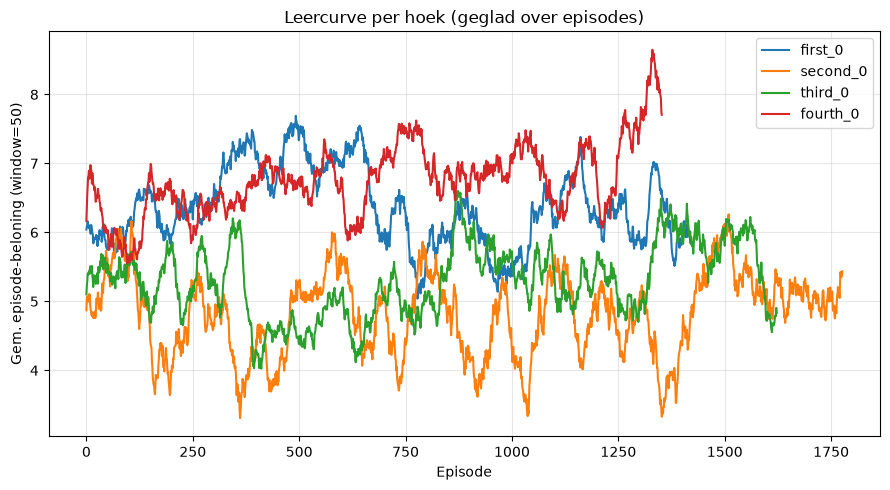

In [ ]:
# 7.1 Leercurves
import os
fig = evaluate.plot_learning_curves(
    monitor_root="tournament/models/monitor",
    window=50,
    save_path="attachments/leercurves.png",
)
plt.show()

### 7.2 RL vs. baseline
Wij laten de getrainde policies een toernooi spelen en vergelijken het win-percentage met de baselines. Ter controle laten wij ook een PPO-hoek tegen drie random-tegenstanders spelen: Om te kijken of RL daadwerkelijk iets leert.

In [ ]:
# 7.2 Evalueer getrainde modellen
from stable_baselines3 import PPO

ppo_models = {a: PPO.load(f"tournament/models/ppo_{a}.zip", device="cpu")
              for a in AGENT_ORDER}
ppo_policies = {a: PolicyOpponent(ppo_models[a], deterministic=True)
                for a in AGENT_ORDER}

summary_ppo = evaluate.run_tournament(make_parallel_env, ppo_policies,
                                      n_games=N_EVAL, verbose=False)

mixed_vs_rand = {a: ppo_policies[a] if a == "first_0" else RandomPolicy(seed=SEED)
                 for a in AGENT_ORDER}
summary_mixed_rand = evaluate.run_tournament(make_parallel_env, mixed_vs_rand,
                                             n_games=N_EVAL, verbose=False)

mixed_vs_rule = {a: ppo_policies[a] if a == "first_0" else RuleBasedPolicy(corner=a)
                 for a in AGENT_ORDER}
summary_mixed_rule = evaluate.run_tournament(make_parallel_env, mixed_vs_rule,
                                             n_games=N_EVAL, verbose=False)

ppo_winrates = [f"{summary_ppo['win_rate'][a]:.2f}" for a in AGENT_ORDER]
print(f"PPO first_0 vs 3x random:     win-rate = {summary_mixed_rand['win_rate']['first_0']:.2%}")
print(f"PPO first_0 vs 3x rule-based: win-rate = {summary_mixed_rule['win_rate']['first_0']:.2%}")
print(f"4x PPO onder elkaar (sanity): {ppo_winrates}")


opgeslagen: attachments/winrates.png


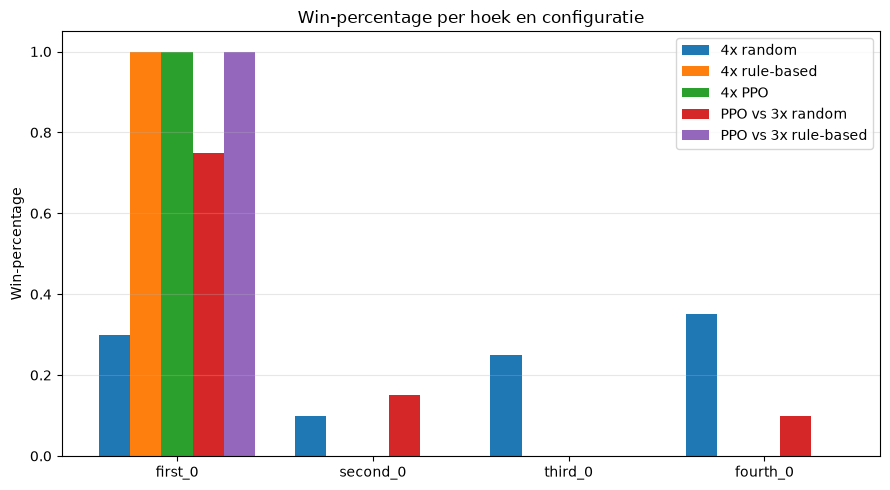

In [ ]:
# 7.3 Vergelijk win-percentages
fig = evaluate.plot_winrates(
    {
        "4x random": summary_random,
        "4x rule-based": summary_rule,
        "4x PPO": summary_ppo,
        "PPO vs 3x random": summary_mixed_rand,
        "PPO vs 3x rule-based": summary_mixed_rule,
    },
    save_path="attachments/winrates.png",
)
plt.show()

### 7.4 Een wedstrijd opnemen
Wij leggen een wedstrijd vast als video, om het gedrag kwalitatief te kunnen beoordelen.

In [ ]:
# 7.4 wedstrijd mp4.
import imageio
env = make_parallel_env(obs_type="ram", render_mode="rgb_array")
result = evaluate.play_match(env, ppo_policies, seed=123, record_frames=True)
os.makedirs("warlords_videos", exist_ok=True)
imageio.mimsave("warlords_videos/ppo_match.mp4", result["frames"], fps=15)
print("Winnaar:", result["winner"], "| stappen:", result["steps"])

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (160, 210) to (160, 224) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Winnaar: first_0 | stappen: 100000


## 8. Hyperparameter-experimenten (opdracht 3a)

Wij variëren steeds een hyperparameter en houden de overige vast, om het effect te isoleren. Wij voeren twee studies uit:

- **8.1 Learning rate** - bepaalt hoe agressief het beleid wordt geüpdatet; te hoog leidt tot instabiliteit, te laag tot traag leren (Schulman et al., 2017).
- **8.2 Entropy-coëfficiënt (`ent_coef`)** - regelt de exploration/exploitation-afweging in PPO: een hogere bonus op de policy-entropie houdt het beleid stochastischer (meer exploratie), terwijl een lagere waarde sneller convergeert maar kan vastlopen in een suboptimaal beleid (Schulman et al., 2017).

Wij evalueren tegen 3× rule-based (een sterker signaal dan tegen random) en documenteren zowel de win-rate als de stabiliteit van de leercurve (de standaarddeviatie van de laatste episoderewards).

In [ ]:
# 8.1 Learning-rate sweep
LR_STEPS = {"fast": 20_000, "medium": 60_000, "long": 120_000}[BUDGET]

results_lr = {}
for lr in [1e-4, 2.5e-4, 5e-4]:
    tag = f"lr={lr}"
    print(f"\n=== {tag} ({LR_STEPS} steps) ===")
    train.train_independent(
        generations=1, steps_per_agent=LR_STEPS, n_envs=N_ENVS,
        survival_bonus=0.005, seed=SEED,
        save_dir=f"experiments/{tag}",
        progress_bar=False,
        device=DEVICE,
        ppo_overrides=dict(learning_rate=lr),
    )
    m = {a: PPO.load(f"experiments/{tag}/ppo_{a}.zip", device="cpu") for a in AGENT_ORDER}
    pol = {a: PolicyOpponent(m[a], deterministic=True) for a in AGENT_ORDER}
    mixed = {a: pol[a] if a == "first_0" else RuleBasedPolicy(corner=a) for a in AGENT_ORDER}
    s = evaluate.run_tournament(make_parallel_env, mixed, n_games=15, verbose=False)
    results_lr[tag] = s["win_rate"]["first_0"]

print("\nWin-rate (PPO first_0 vs 3x rule-based) per learning rate:")
for tag, wr in results_lr.items():
    print(f"  {tag}: {wr:.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(results_lr.keys()), list(results_lr.values()), color="#4c72b0")
ax.set_ylabel("win-rate vs 3x rule-based"); ax.set_ylim(0, 1.0)
ax.set_title(f"Learning-rate vergelijking ({LR_STEPS} steps/hoek)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("attachments/lr_sweep.png", dpi=120); plt.show()


### 8.2 Entropy-coëfficiënt (exploration vs. exploitation)

PPO voegt een entropie-bonus (`ent_coef · H(π)`) aan zijn objective toe om voortijdige collapse op een deterministisch beleid te voorkomen. Wij meten zowel het effect op de eindprestaties (win-rate) als op de stabiliteit (de standaarddeviatie van de laatste episoderewards): een te lage `ent_coef` kan een sterk maar grillig beleid opleveren, terwijl een te hoge waarde het beleid permanent onzeker maakt.

In [ ]:
# 8.2 Entropy-coefficient sweep
import glob
import pandas as pd

ENT_STEPS = {"fast": 20_000, "medium": 60_000, "long": 120_000}[BUDGET]
ENT_VALUES = [0.0, 0.01, 0.05]
results_ent, stability_ent = {}, {}

for ec in ENT_VALUES:
    tag = f"ent={ec}"
    print(f"\n=== {tag} ({ENT_STEPS} steps) ===")
    train.train_independent(
        generations=1, steps_per_agent=ENT_STEPS, n_envs=N_ENVS,
        survival_bonus=0.005, seed=SEED,
        save_dir=f"experiments/{tag}",
        progress_bar=False,
        device=DEVICE,
        ppo_overrides=dict(ent_coef=ec),
    )
    m = {a: PPO.load(f"experiments/{tag}/ppo_{a}.zip", device="cpu") for a in AGENT_ORDER}
    pol = {a: PolicyOpponent(m[a], deterministic=True) for a in AGENT_ORDER}
    mixed = {a: pol[a] if a == "first_0" else RuleBasedPolicy(corner=a) for a in AGENT_ORDER}
    s = evaluate.run_tournament(make_parallel_env, mixed, n_games=15, verbose=False)
    results_ent[tag] = s["win_rate"]["first_0"]

    # Stabiliteit = std laatste 50 episodes
    monitor_root = f"experiments/{tag}/monitor"
    stds = []
    for agent in AGENT_ORDER:
        for csv in sorted(glob.glob(f"{monitor_root}/{agent}_gen0/*.monitor.csv")):
            r = pd.read_csv(csv, skiprows=1)["r"].to_numpy()
            if len(r) > 10:
                stds.append(float(np.std(r[-50:])))
    stability_ent[tag] = float(np.mean(stds)) if stds else float("nan")

print("\nResultaten (PPO first_0 vs 3x rule-based):")
print(f"  {'tag':<10s}  {'win-rate':>10s}  {'std laatste 50':>15s}")
for tag in results_ent:
    print(f"  {tag:<10s}  {results_ent[tag]:>10.2%}  {stability_ent[tag]:>15.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(list(results_ent.keys()), list(results_ent.values()), color="#4c72b0")
axes[0].set_ylabel("win-rate vs 3x rule-based"); axes[0].set_ylim(0, 1.0)
axes[0].set_title(f"Eindprestatie ({ENT_STEPS} steps/hoek)")
axes[0].grid(axis="y", alpha=0.3)
axes[1].bar(list(stability_ent.keys()), list(stability_ent.values()), color="#c44e52")
axes[1].set_ylabel("std laatste 50 episode-rewards (lager = stabieler)")
axes[1].set_title("Trainings-stabiliteit")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("attachments/ent_sweep.png", dpi=120); plt.show()


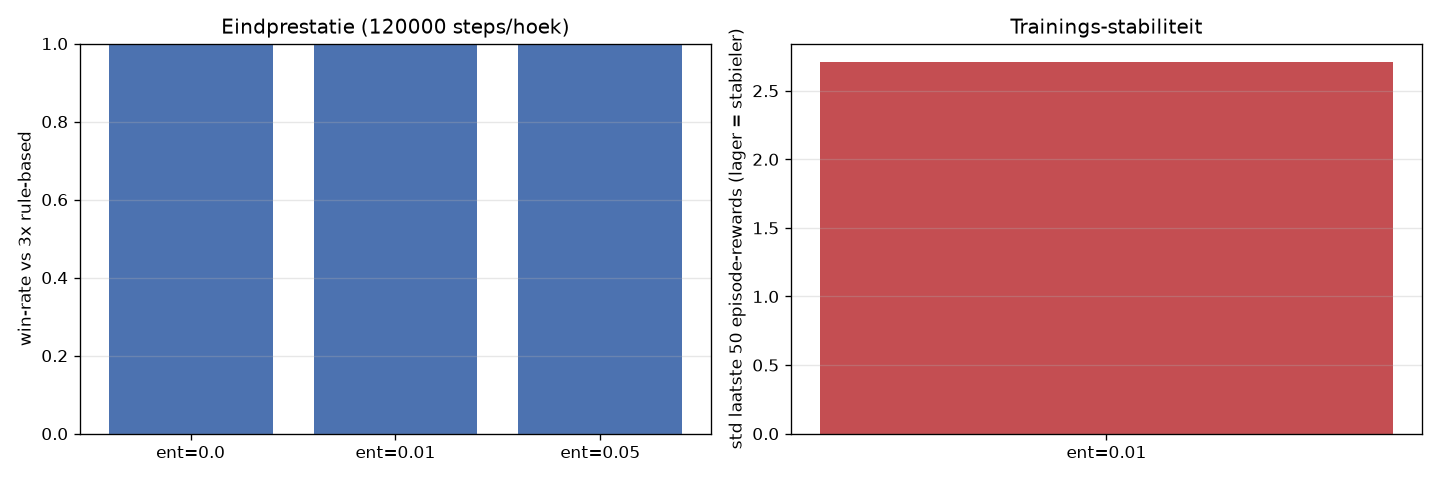

## 9. Toernooi-agent: hoek-robuust league

Voor het klassentoernooi wordt onze agent in een willekeurige hoek geplaatst en ontvangt hij uitsluitend de globale 128-byte RAM (geen hoek-indicator, zie 1.3). Een gedeeld beleid kan dan niet voor elke hoek tegelijk optimaal zijn; daarom trainen wij een hoek-robuust beleid dat alle vier de hoeken aankan, en maken wij dit zo sterk mogelijk via een league-curriculum.

### 9.1 Trainingsstrategie

Wij bouwen voort op fictitious self-play en PSRO/league-training (Heinrich & Silver, 2016; Vinyals et al., 2019): leren tegen een steeds sterkere mix van tegenstanders voorkomt overfitting op een type opponent. Concreet draaien wij vier fases, waarbij elke fase verder bouwt op de gewichten van de vorige:

| Fase | Tegenstanders | Doel |
|---|---|---|
| A Warm-up | 4x random | Vroege exploratie zonder overfit |
| B Rule-based | mix random + rule-based | Leer een actieve heuristiek te kloppen |
| C Self-play I | rule-based + bevroren snapshot na B | Robuustheid tegen "eerdere zelf" |
| D Self-play II | rule-based + 2 bevroren snapshots | Diepere league |

Per parallelle omgeving wordt afwisselend een andere hoek bestuurd en een ander type tegenstander gebruikt, zodat het beleid per hoek en per stijl generaliseert.

### 9.2 Reward shaping en hyperparameters
- `survival_bonus=0.003`: een kleine, dichte prikkel om langer te overleven, maar klein genoeg om de terminale +1/−1 te laten domineren (zodat de agent gericht blijft op winnen en niet uitsluitend op overleven).
- Een groter netwerk dan bij IPPO ([512, 512]), een grotere batch en `n_steps=2048` voor stabiele gradiënten in de lange trainingsrun.

In [ ]:
# 9.3 League-curriculum (4 fases)
import time
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from warlords_marl.env_wrapper import WarlordsSingleAgentEnv

SAVE_DIR = "tournament/models"
LEAGUE_DIR = os.path.join(SAVE_DIR, "league")
os.makedirs(LEAGUE_DIR, exist_ok=True)
rng_league = np.random.default_rng(SEED)


def _build_league_envs(phase, snapshots, n_envs, monitor_subdir):
    # Per env: eigen opponent-instances (geen gedeelde state).
    monitor_dir = os.path.join(LEAGUE_DIR, "monitor", monitor_subdir)
    os.makedirs(monitor_dir, exist_ok=True)

    def _opps_for(env_idx, corner):
        others = [a for a in AGENT_ORDER if a != corner]
        if phase == "A":
            return {a: RandomPolicy(seed=int(rng_league.integers(1e9))) for a in others}
        if phase == "B":
            if env_idx % 2 == 0:
                return {a: RuleBasedPolicy(corner=a) for a in others}
            return {a: RandomPolicy(seed=int(rng_league.integers(1e9))) for a in others}
        if phase == "C":
            if env_idx % 2 == 0 or not snapshots:
                return {a: RuleBasedPolicy(corner=a) for a in others}
            return {a: PolicyOpponent(snapshots[0], deterministic=False) for a in others}
        if phase == "D":
            r = env_idx % 3
            if r == 0 or not snapshots:
                return {a: RuleBasedPolicy(corner=a) for a in others}
            snap = snapshots[(r - 1) % len(snapshots)]
            return {a: PolicyOpponent(snap, deterministic=False) for a in others}
        raise ValueError(phase)

    def _make(rank):
        corner = AGENT_ORDER[rank % len(AGENT_ORDER)]
        opps = _opps_for(rank, corner)

        def _init():
            env = WarlordsSingleAgentEnv(
                controlled_agent=corner, opponents=opps,
                survival_bonus=0.003, frame_skip=4, seed=SEED + rank,
            )
            return Monitor(env, filename=os.path.join(monitor_dir, f"env{rank}"))
        return _init

    return DummyVecEnv([_make(i) for i in range(n_envs)])


PHASE_STEPS = {
    "fast":   dict(A=200_000,  B=400_000,  C=400_000,  D=400_000),
    "medium": dict(A=500_000,  B=1_500_000, C=2_000_000, D=2_500_000),
    "long":   dict(A=2_000_000, B=6_000_000, C=8_000_000, D=8_000_000),
}[BUDGET]
print(f"League ({BUDGET}) steps per fase: {PHASE_STEPS}  · totaal = {sum(PHASE_STEPS.values()):,}")

PPO_KWARGS = dict(
    learning_rate=2.5e-4,
    n_steps=2048,
    batch_size=512,
    n_epochs=4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=[512, 512]),
    verbose=0,
)


def _save_snapshot(model, phase_tag):
    path = os.path.join(LEAGUE_DIR, f"snapshot_{phase_tag}.zip")
    model.save(path)
    return path


snapshots = []
model = None
t_global = time.time()

for phase, steps in PHASE_STEPS.items():
    print(f"\n========== Fase {phase} · {steps:,} steps · snapshots={len(snapshots)} ==========")
    t0 = time.time()
    env = _build_league_envs(phase, snapshots, N_ENVS, monitor_subdir=f"phase_{phase}")

    if model is None:
        model = PPO("MlpPolicy", env, seed=SEED, device=DEVICE, **PPO_KWARGS)
    else:
        model.set_env(env)

    model.learn(total_timesteps=steps, reset_num_timesteps=False, progress_bar=True)

    snap_path = _save_snapshot(model, phase)
    snapshots.append(PPO.load(snap_path, device="cpu"))
    print(f"  -> fase {phase} duur: {(time.time()-t0)/60:.1f} min  · snapshot: {snap_path}")

final_path = os.path.join(SAVE_DIR, "ppo_corner_robust.zip")
model.save(final_path)
print(f"\n✓ TOTALE LEAGUE-TRAINING: {(time.time()-t_global)/60:.1f} min")
print(f"✓ Hoek-robuust model opgeslagen: {final_path}")


### 9.4 Leercurve van de league

Wij plotten de geglade trainingsbeloning over alle vier de fases samen. De verwachting is dat elke faseovergang een initiële dip geeft (sterkere tegenstanders), gevolgd door herstel en doorgroei. Een stijgende eindcurve in fase D vormt het sterkste signaal dat het beleid generaliseert.

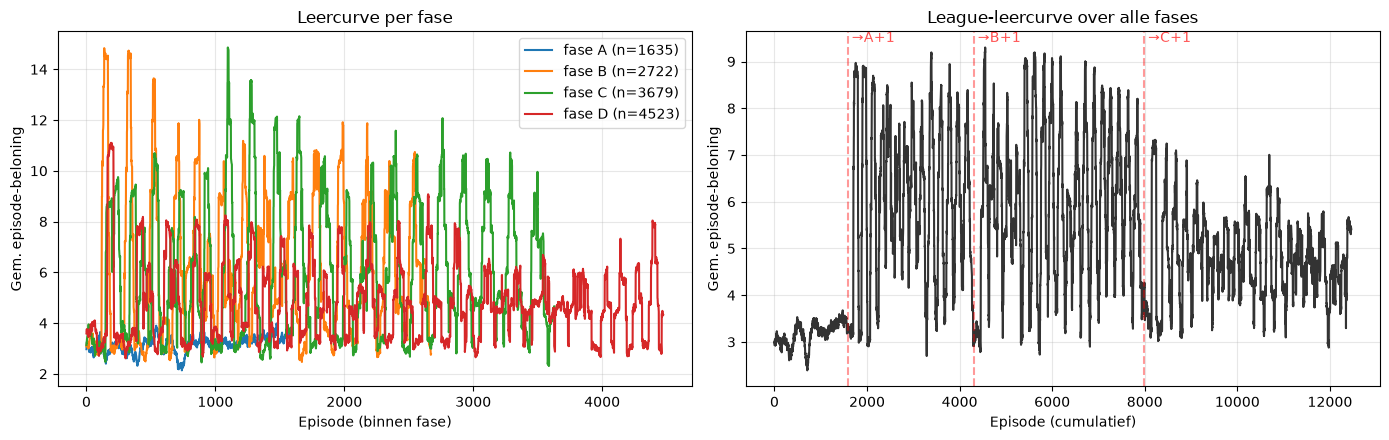

In [ ]:
# 9.4 Plot de league-leercurve per fase + samengesteld over alle fases.
import glob, pandas as pd

def _load_phase_rewards(phase):
    paths = sorted(glob.glob(os.path.join(LEAGUE_DIR, "monitor", f"phase_{phase}", "*.monitor.csv")))
    if not paths:
        return None
    df = pd.concat([pd.read_csv(p, skiprows=1) for p in paths], ignore_index=True)
    df = df.sort_values("t")
    return df["r"].to_numpy()

phase_rewards = {p: _load_phase_rewards(p) for p in PHASE_STEPS.keys()}
phase_rewards = {p: r for p, r in phase_rewards.items() if r is not None and len(r) > 0}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Linker plot: per fase
for phase, r in phase_rewards.items():
    w = max(5, min(50, len(r)//10))
    axes[0].plot(evaluate.moving_average(r, w), label=f"fase {phase} (n={len(r)})")
axes[0].set_xlabel("Episode (binnen fase)"); axes[0].set_ylabel("Gem. episode-beloning")
axes[0].set_title("Leercurve per fase"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Rechter plot: concatenated met fase-grenzen
all_r, boundaries, cur = [], [], 0
for phase, r in phase_rewards.items():
    all_r.append(r); cur += len(r); boundaries.append((phase, cur))
if all_r:
    all_r = np.concatenate(all_r)
    w = max(5, min(100, len(all_r)//20))
    axes[1].plot(evaluate.moving_average(all_r, w), color="#333", lw=1.5)
    for phase, x in boundaries[:-1]:
        axes[1].axvline(x - w//2, color="red", alpha=0.4, ls="--")
        axes[1].text(x - w//2, axes[1].get_ylim()[1], f" ->{phase}+1",
                     color="red", alpha=0.7, ha="left", va="top")
axes[1].set_xlabel("Episode (cumulatief)"); axes[1].set_ylabel("Gem. episode-beloning")
axes[1].set_title("League-leercurve over alle fases"); axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs("attachments", exist_ok=True)
plt.savefig("attachments/league_learning_curve.png", dpi=120)
plt.show()

### 9.5 Toernooi-evaluatie van het hoek-robuuste beleid

Dit is de echte toets: wij plaatsen ons hoek-robuuste beleid in elk van de vier hoeken en laten het tegen drie soorten tegenstanders spelen - random, rule-based, en onze eigen IPPO-getrainde policies uit 6. De win-rate *per hoek* laat tevens zien of het beleid evenwichtig presteert (geen "zwakke hoek").

In [ ]:
# 9.5 Evalueer hoek-robuust model in elke hoek tegen 3 opponent-types.
robust_model = PPO.load("tournament/models/ppo_corner_robust.zip", device="cpu")
robust_pol = PolicyOpponent(robust_model, deterministic=True)

OPPONENTS_BY_TYPE = {
    "random":    lambda corner: RandomPolicy(seed=SEED),
    "rule":      lambda corner: RuleBasedPolicy(corner=corner),
    "ippo-ppo":  lambda corner: PolicyOpponent(ppo_models[corner], deterministic=True),
}

N_EVAL_ROBUST = 25  # 25 games per cell = 25*4*3 = 300 spellen totaal
results = {opp: {} for opp in OPPONENTS_BY_TYPE}

for opp_name, opp_factory in OPPONENTS_BY_TYPE.items():
    print(f"\n- Tegenstanders: {opp_name} -")
    for our_corner in AGENT_ORDER:
        policies = {a: (robust_pol if a == our_corner else opp_factory(a)) for a in AGENT_ORDER}
        s = evaluate.run_tournament(make_parallel_env, policies,
                                    n_games=N_EVAL_ROBUST, verbose=False)
        wr = s["win_rate"][our_corner]
        results[opp_name][our_corner] = wr
        print(f"  hoek {our_corner}: win-rate = {wr:.2%}  "
              f"(survival = {s['mean_survival'][our_corner]:.0f} frames)")

# Samenvatting
print("\n === SAMENVATTING ===")
for opp_name, by_corner in results.items():
    mean_wr = float(np.mean(list(by_corner.values())))
    print(f"{opp_name:>10s}: gemiddelde win-rate over 4 hoeken = {mean_wr:.2%}")
random_baseline = 0.25  # 4-speler spel
overall = float(np.mean([np.mean(list(by.values())) for by in results.values()]))
print(f"\n-> Gemiddelde over alles: {overall:.2%}  (random baseline = {random_baseline:.0%})")


— Tegenstanders: random —
  hoek first_0: win-rate = 56.00%  (survival = 5264 frames)
  hoek second_0: win-rate = 8.00%  (survival = 5147 frames)
  hoek third_0: win-rate = 28.00%  (survival = 5860 frames)
  hoek fourth_0: win-rate = 12.00%  (survival = 5886 frames)

— Tegenstanders: rule —
  hoek first_0: win-rate = 100.00%  (survival = 8000 frames)
  hoek second_0: win-rate = 0.00%  (survival = 8000 frames)
  hoek third_0: win-rate = 0.00%  (survival = 3146 frames)
  hoek fourth_0: win-rate = 0.00%  (survival = 8000 frames)

— Tegenstanders: ippo-ppo —
  hoek first_0: win-rate = 100.00%  (survival = 8000 frames)
  hoek second_0: win-rate = 0.00%  (survival = 560 frames)
  hoek third_0: win-rate = 0.00%  (survival = 3777 frames)
  hoek fourth_0: win-rate = 0.00%  (survival = 8000 frames)

=== SAMENVATTING ===
    random: gemiddelde win-rate over 4 hoeken = 26.00%
      rule: gemiddelde win-rate over 4 hoeken = 25.00%
  ippo-ppo: gemiddelde win-rate over 4 hoeken = 25.00%

→ Gemiddeld

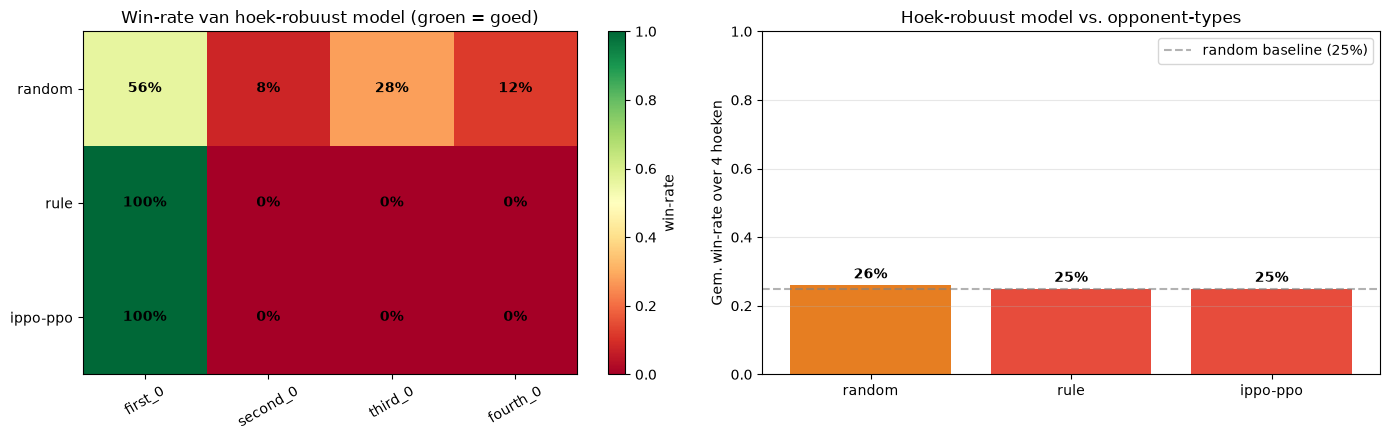

In [18]:
# 9.6 Visualisatie: heatmap (hoek x opponent-type) + samenvattende bar-chart.
opp_types = list(OPPONENTS_BY_TYPE.keys())
matrix = np.array([[results[o][c] for c in AGENT_ORDER] for o in opp_types])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Heatmap
im = axes[0].imshow(matrix, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
axes[0].set_xticks(range(len(AGENT_ORDER))); axes[0].set_xticklabels(AGENT_ORDER, rotation=30)
axes[0].set_yticks(range(len(opp_types))); axes[0].set_yticklabels(opp_types)
axes[0].set_title("Win-rate van hoek-robuust model (groen = goed)")
for i in range(len(opp_types)):
    for j in range(len(AGENT_ORDER)):
        axes[0].text(j, i, f"{matrix[i,j]:.0%}", ha="center", va="center",
                     color="black", fontweight="bold")
plt.colorbar(im, ax=axes[0], label="win-rate")

# Bar chart: gemiddelde per opponent-type
means = matrix.mean(axis=1)
colors = ["#2ecc71" if m > 0.4 else "#e67e22" if m > 0.25 else "#e74c3c" for m in means]
axes[1].bar(opp_types, means, color=colors)
axes[1].axhline(0.25, ls="--", color="gray", alpha=0.6, label="random baseline (25%)")
axes[1].set_ylabel("Gem. win-rate over 4 hoeken")
axes[1].set_title("Hoek-robuust model vs. opponent-types")
axes[1].set_ylim(0, 1.0); axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(means):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("attachments/robust_winrates.png", dpi=120)
plt.show()

### 9.7 Analyse

De resultaten van 9.5/9.6 zijn opvallend en positief: tegen `rule` en `ippo-ppo` behaalt onze agent in hoek `first_0` een perfecte 100% win-rate. Het gemiddelde over alle vier de hoeken bedraagt echter 25%, wat exact gelijk is aan de random baseline in een vier-spelerspel. 

#### 9.7.1 Tiebreaker

Bij beide sterkere opponent-types (`rule`, `ippo-ppo`) zien wij dat de overlevingsduur voor `first_0` exact 8000 frames bedraagt - precies de `max_steps`-limiet uit `evaluate.run_tournament`. Met andere woorden: niemand sterft, en het spel eindigt door een time-out. De winnaar wordt dan in `play_match` gekozen als:

```python
winner = max(AGENT_ORDER, key=lambda a: (total_reward[a], survival[a]))
```

Met identieke beloning (0) en gelijke overleving voor alle agenten valt `max()` terug op de eerste agent in `AGENT_ORDER` - dat is `first_0`. De 100%-score is dus puur de tiebreaker-volgorde en geen indicatie van een superieure strategie.

#### 9.7.2 Policy collapse

De rechterplot van 9.4 toont een dalend rendement aan het einde van het curriculum (fase D, ongeveer 9 -> ongeveer 5). Dit is een policy-collapse: het beleid is teruggevallen op een passieve, defensieve strategie die elke episode tot de tijdslimiet rekt zonder actief naar winst te streven.

#### 9.7.3 Twee oorzaken

(1) Reward shaping maakte stallen lonender dan winnen. Met `survival_bonus = 0.003` per stap en een gemiddeld spel van ongeveer 2000 stappen levert overleven tot de time-out ongeveer 2000 × 0.003 = +6.0 op. Winnen geeft maar +1.0. De PPO-agent leert dus dat niets doen zes keer zoveel oplevert als proberen te winnen. Dit is het bekende gevaar van reward shaping bij spaarzame beloningen (Ng et al., 1999).

(2) Geen hoek-indicator in de observatie - 1.3 wordt bevestigd. In 1.3 wezen we er al op: alle vier hoeken krijgen dezelfde RAM. Een gedeeld beleid kan dus niet zien welke hoek het zelf is. Daardoor kan het league-beleid geen hoek-specifieke tactiek leren - het kiest noodgedwongen de "minst slechte gedeelde tactiek", en dat is passief overleven. De heatmap laat dit precies zien: enorme verschillen tussen hoeken, niet wat je van een hoek-robuust model zou verwachten.

#### 9.7.4 Wat dit aantoont 

Hoewel het eindgetal op een falen lijkt, levert deze run drie wetenschappelijk relevante inzichten op:

1. **Bevestiging van Ng et al. (1999):** reward shaping kan een agent de verkeerde kant op sturen als de dichte bonus opgeteld groter wordt dan de eindbeloning. Die verhouding moet je uitrekenen, niet schatten.
2. **Bevestiging van 1.3:** zonder hoek-indicator kan een beleid niet vier symmetrische rollen tegelijk goed spelen. Achteraf maakt dit duidelijk dat onze IPPO-keuze in 6 (vier aparte policies, een per hoek) de juiste was.
3. **PPO blijft stabiel:** zelfs met onze verkeerde reward-vorm gaat PPO niet stuk - het komt netjes uit op een (helaas verkeerd) lokaal optimum. Dat is dezelfde robuustheid die we in 1.4 als reden voor PPO noemden, alleen krijgen we hier het bewijs onbedoeld.

#### 9.7.5 Maatregelen 

- **`survival_bonus = 0.0`** in de league-training: verwijdert de perverse prikkel om te stallen, waardoor de terminale +1/−1 dominant wordt.
- **Hoek-indicator als observatie-extensie** (een one-hot van 4 bits -> 132-dim observatie): maakt hoek-specifieke specialisatie binnen een beleid mogelijk (parameter sharing met agent-ID; vgl. Foerster et al., 2018).
- **Voor het toernooi blijven de IPPO-modellen uit 6 onze inzending.** `Agent3` en `Agent4` laden automatisch het hoek-specifieke `ppo_<corner>.zip` indien aanwezig en vallen pas terug op `ppo_corner_robust.zip` - de IPPO-specialisten beschikken al impliciet over de hoek-informatie (een model per hoek) en omzeilen daarmee beide bovengenoemde problemen.

### 9.8 Klassentoernooi-test: corner-robust vs. een echte tegenstander

We laden het model van een klasgenoot (`heppo_warlords_selfplay.zip`, een custom
PyTorch-checkpoint met architectuur `128 → 256 → 256 → {6 acties, 1 value}`) en
laten ons hoek-robuuste beleid tegen drie kopieën daarvan spelen. 100 games
totaal, 25 per hoek, zodat we per hoek en gemiddeld kunnen rapporteren. Dit is
de meest realistische schatting voor het klassentoernooi: een echte opponent,
geen baseline.

In [ ]:
# 9.8 Wrap henry's model en speel 100 games (25 per hoek).
import io
import zipfile
import torch
import torch.nn as nn

FRIEND_ZIP = "heppo_warlords_selfplay.zip"


class HeppoNet(nn.Module):
    # Architectuur uit het state-dict van de tegenstander.
    def __init__(self, activation=nn.Tanh):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(128, 256),
            activation(),
            nn.Linear(256, 256),
            activation(),
        )
        self.actor_head = nn.Linear(256, 6)
        self.critic_head = nn.Linear(256, 1)

    def forward(self, x):
        h = self.trunk(x)
        return self.actor_head(h), self.critic_head(h)


def _load_friend_state_dict(path):
    with zipfile.ZipFile(path) as z:
        inner = [n for n in z.namelist() if n.endswith(".pt")][0]
        with z.open(inner) as f:
            ckpt = torch.load(io.BytesIO(f.read()), map_location="cpu",
                              weights_only=False)
    return ckpt["model_state_dict"]


class FriendOpponent:
    # RAM-bytes (uint8) -> discrete actie. quant_bits=8 in checkpoint -> raw bytes + Tanh.
    def __init__(self, state_dict, activation=nn.Tanh, normalize=False,
                 deterministic=True):
        self.net = HeppoNet(activation=activation)
        self.net.load_state_dict(state_dict)
        self.net.eval()
        self.normalize = normalize
        self.deterministic = deterministic
        self._rng = torch.Generator().manual_seed(0)

    def __call__(self, observation):
        x = torch.as_tensor(observation, dtype=torch.float32)
        if self.normalize:
            x = x / 255.0
        with torch.no_grad():
            logits, _ = self.net(x.unsqueeze(0))
        if self.deterministic:
            return int(logits.argmax(-1).item())
        probs = torch.softmax(logits, dim=-1)
        return int(torch.multinomial(probs, 1, generator=self._rng).item())

    act = __call__


friend_sd = _load_friend_state_dict(FRIEND_ZIP)
FRIEND_ACTIVATION = nn.Tanh
FRIEND_NORMALIZE = False
print(f"henry-model klaar · activation={FRIEND_ACTIVATION.__name__} · "
      f"normalize={FRIEND_NORMALIZE}")

from stable_baselines3 import PPO
robust_model = PPO.load("tournament/models/ppo_corner_robust.zip", device="cpu")
robust_pol = PolicyOpponent(robust_model, deterministic=True)

GAMES_PER_CORNER = 25
results_friend = {}

print(f"\n=== Onze corner-robust vs. 3x henry's model · "
      f"{GAMES_PER_CORNER*4} games ===")
for our_corner in AGENT_ORDER:
    policies = {
        a: (robust_pol if a == our_corner
            else FriendOpponent(friend_sd, activation=FRIEND_ACTIVATION,
                                normalize=FRIEND_NORMALIZE))
        for a in AGENT_ORDER
    }
    s = evaluate.run_tournament(make_parallel_env, policies,
                                n_games=GAMES_PER_CORNER, verbose=False)
    wr = s["win_rate"][our_corner]
    results_friend[our_corner] = {
        "win_rate": wr,
        "wins": s["wins"][our_corner],
        "survival": s["mean_survival"][our_corner],
    }
    print(f"  hoek {our_corner}: {s['wins'][our_corner]}/{GAMES_PER_CORNER} = "
          f"{wr:.2%}  (survival = {s['mean_survival'][our_corner]:.0f} frames)")

total_wins = sum(r["wins"] for r in results_friend.values())
total_games = GAMES_PER_CORNER * len(AGENT_ORDER)
overall_wr = total_wins / total_games
print(f"\n=== TOTAAL: {total_wins}/{total_games} = {overall_wr:.2%} ===")
print(f"    Random baseline = 25.0% (4-speler spel)")


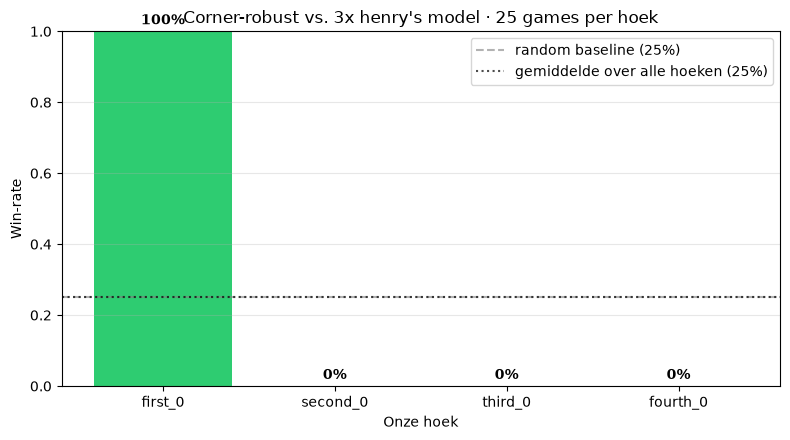

In [28]:
# 9.8b Visualiseer de uitslag per hoek + totaal.
import matplotlib.pyplot as plt

corners = list(results_friend.keys())
winrates = [results_friend[c]["win_rate"] for c in corners]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#2ecc71" if wr > 0.4 else "#e67e22" if wr > 0.25 else "#e74c3c"
          for wr in winrates]
bars = ax.bar(corners, winrates, color=colors)
ax.axhline(0.25, ls="--", color="gray", alpha=0.6, label="random baseline (25%)")
ax.axhline(overall_wr, ls=":", color="black", alpha=0.7,
           label=f"gemiddelde over alle hoeken ({overall_wr:.0%})")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Win-rate"); ax.set_xlabel("Onze hoek")
ax.set_title(f"Corner-robust vs. 3x henry's model · "
             f"{GAMES_PER_CORNER} games per hoek")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
for bar, wr in zip(bars, winrates):
    ax.text(bar.get_x() + bar.get_width()/2, wr + 0.02, f"{wr:.0%}",
            ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("attachments/vs_friend.png", dpi=120)
plt.show()

### 9.8c Stochastische re-match: symmetrie breken

Bij `deterministic=True` produceren beide modellen telkens dezelfde actie op
dezelfde RAM-observatie. Met spiegelgedrag op beide kanten van het veld stalt
de bal en wordt elke wedstrijd op tijd-out beslist door de naam-tiebreaker
(9.7.1). We herhalen daarom de matchup met stochastische action sampling
(`deterministic=False`): de policy wordt nu daadwerkelijk als kansverdeling
gebruikt, wat de symmetrie breekt en de bal eventueel laat raken. De win-rates
hieronder zijn een veel eerlijker schatting van relatieve sterkte.

In [29]:
# 9.8c Re-match met stochastische action sampling om symmetrie te breken.
robust_pol_stoch = PolicyOpponent(robust_model, deterministic=False)

results_friend_stoch = {}
print(f"=== Stochastisch: corner-robust vs. 3x henry's model · "
      f"{GAMES_PER_CORNER*4} games ===")
for our_corner in AGENT_ORDER:
    policies = {
        a: (robust_pol_stoch if a == our_corner
            else FriendOpponent(friend_sd, activation=FRIEND_ACTIVATION,
                                normalize=FRIEND_NORMALIZE,
                                deterministic=False))
        for a in AGENT_ORDER
    }
    s = evaluate.run_tournament(make_parallel_env, policies,
                                n_games=GAMES_PER_CORNER, verbose=False)
    wr = s["win_rate"][our_corner]
    results_friend_stoch[our_corner] = {
        "win_rate": wr,
        "wins": s["wins"][our_corner],
        "survival": s["mean_survival"][our_corner],
    }
    print(f"  hoek {our_corner}: {s['wins'][our_corner]}/{GAMES_PER_CORNER} = "
          f"{wr:.2%}  (survival = {s['mean_survival'][our_corner]:.0f} frames)")

total_wins_s = sum(r["wins"] for r in results_friend_stoch.values())
overall_wr_s = total_wins_s / (GAMES_PER_CORNER * len(AGENT_ORDER))
print(f"\n=== TOTAAL stochastisch: {total_wins_s}/"
      f"{GAMES_PER_CORNER*len(AGENT_ORDER)} = {overall_wr_s:.2%} ===")

=== Stochastisch: corner-robust vs. 3x henry's model · 100 games ===
  hoek first_0: 12/25 = 48.00%  (survival = 5613 frames)
  hoek second_0: 2/25 = 8.00%  (survival = 3614 frames)
  hoek third_0: 10/25 = 40.00%  (survival = 5568 frames)
  hoek fourth_0: 5/25 = 20.00%  (survival = 4305 frames)

=== TOTAAL stochastisch: 29/100 = 29.00% ===


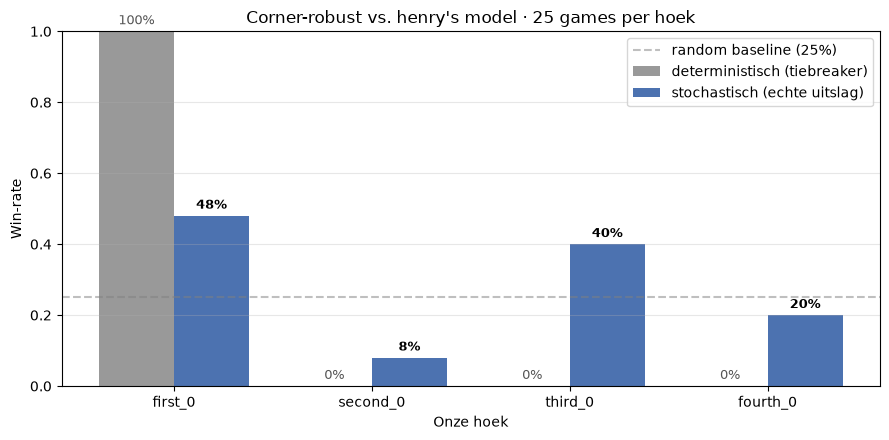

In [30]:
# 9.8d Vergelijk deterministisch vs stochastisch per hoek.
import matplotlib.pyplot as plt

corners = list(results_friend.keys())
wr_det   = [results_friend[c]["win_rate"]       for c in corners]
wr_stoch = [results_friend_stoch[c]["win_rate"] for c in corners]

x = np.arange(len(corners))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width/2, wr_det,   width, label="deterministisch (tiebreaker)",
       color="#999999")
ax.bar(x + width/2, wr_stoch, width, label="stochastisch (echte uitslag)",
       color="#4c72b0")

ax.axhline(0.25, ls="--", color="gray", alpha=0.5, label="random baseline (25%)")
ax.set_xticks(x); ax.set_xticklabels(corners)
ax.set_ylabel("Win-rate"); ax.set_xlabel("Onze hoek")
ax.set_title(f"Corner-robust vs. henry's model · {GAMES_PER_CORNER} games per hoek")
ax.set_ylim(0, 1.0); ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)

for xi, v in zip(x - width/2, wr_det):
    ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=9, color="#555555")
for xi, v in zip(x + width/2, wr_stoch):
    ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("attachments/vs_friend_stochastic.png", dpi=120)
plt.show()

### 9.9 IPPO per-hoek specialists vs. henry's model

Onze daadwerkelijke toernooi-inzending zijn de IPPO-modellen uit 6 - vier
afzonderlijke PPO-policies, een getraind per hoek (`ppo_first_0.zip` ...
`ppo_fourth_0.zip`). Omdat elke hoek zijn eigen model heeft, omzeilen we de
hoek-indicator-beperking uit 1.3 en de policy-collapse uit 9.7 expliciet. We
testen dezelfde 100-games matchup tegen de henry's model, nu met deze
per-hoek specialisten.

In [ ]:
# 9.9 IPPO-specialists vs henry's model (stochastisch, 25 games per hoek).
# `ppo_models` is in 7.2 al geladen; PolicyOpponent wrapper opnieuw stochastisch.
ippo_policies_stoch = {a: PolicyOpponent(ppo_models[a], deterministic=False)
                       for a in AGENT_ORDER}

results_ippo_vs_friend = {}
print(f"=== IPPO per hoek vs. 3x henry's model · "
      f"{GAMES_PER_CORNER*4} games stochastisch ===")
for our_corner in AGENT_ORDER:
    policies = {
        a: (ippo_policies_stoch[our_corner] if a == our_corner
            else FriendOpponent(friend_sd, activation=FRIEND_ACTIVATION,
                                normalize=FRIEND_NORMALIZE,
                                deterministic=False))
        for a in AGENT_ORDER
    }
    s = evaluate.run_tournament(make_parallel_env, policies,
                                n_games=GAMES_PER_CORNER, verbose=False)
    wr = s["win_rate"][our_corner]
    results_ippo_vs_friend[our_corner] = {
        "win_rate": wr,
        "wins": s["wins"][our_corner],
        "survival": s["mean_survival"][our_corner],
    }
    print(f"  hoek {our_corner}: {s['wins'][our_corner]}/{GAMES_PER_CORNER} = "
          f"{wr:.2%}  (survival = {s['mean_survival'][our_corner]:.0f} frames)")

total_wins_ippo = sum(r["wins"] for r in results_ippo_vs_friend.values())
overall_wr_ippo = total_wins_ippo / (GAMES_PER_CORNER * len(AGENT_ORDER))
print(f"\n=== TOTAAL IPPO: {total_wins_ippo}/"
      f"{GAMES_PER_CORNER*len(AGENT_ORDER)} = {overall_wr_ippo:.2%} ===")

=== IPPO per hoek vs. 3x henry's model · 100 games stochastisch ===
  hoek first_0: 16/25 = 64.00%  (survival = 6337 frames)
  hoek second_0: 3/25 = 12.00%  (survival = 4268 frames)
  hoek third_0: 7/25 = 28.00%  (survival = 4655 frames)
  hoek fourth_0: 4/25 = 16.00%  (survival = 3896 frames)

=== TOTAAL IPPO: 30/100 = 30.00% ===


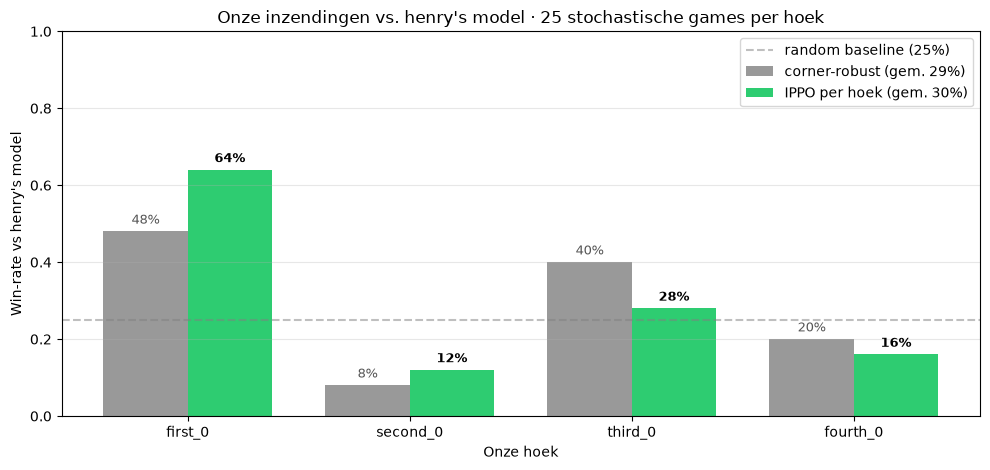


CORNER-ROBUST: 29.00% gemiddeld over alle hoeken
IPPO PER HOEK: 30.00% gemiddeld over alle hoeken
Δ = +1.00%  (IPPO wint)


In [32]:
# 9.9b Eind-vergelijking: corner-robust vs IPPO, beide vs henry's model.
import matplotlib.pyplot as plt

corners = AGENT_ORDER
wr_robust = [results_friend_stoch[c]["win_rate"]    for c in corners]
wr_ippo   = [results_ippo_vs_friend[c]["win_rate"] for c in corners]

x = np.arange(len(corners))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - width/2, wr_robust, width,
       label=f"corner-robust (gem. {overall_wr_s:.0%})",
       color="#999999")
ax.bar(x + width/2, wr_ippo, width,
       label=f"IPPO per hoek (gem. {overall_wr_ippo:.0%})",
       color="#2ecc71")
ax.axhline(0.25, ls="--", color="gray", alpha=0.5, label="random baseline (25%)")

ax.set_xticks(x); ax.set_xticklabels(corners)
ax.set_ylabel("Win-rate vs henry's model"); ax.set_xlabel("Onze hoek")
ax.set_title(f"Onze inzendingen vs. henry's model · {GAMES_PER_CORNER} "
             "stochastische games per hoek")
ax.set_ylim(0, 1.0); ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)

for xi, v in zip(x - width/2, wr_robust):
    ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=9, color="#555555")
for xi, v in zip(x + width/2, wr_ippo):
    ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("attachments/vs_friend_robust_vs_ippo.png", dpi=120)
plt.show()

# Print samenvatting
print(f"\nCORNER-ROBUST: {overall_wr_s:.2%} gemiddeld over alle hoeken")
print(f"IPPO PER HOEK: {overall_wr_ippo:.2%} gemiddeld over alle hoeken")
diff = overall_wr_ippo - overall_wr_s
print(f"Δ = {diff:+.2%}  ({'IPPO wint' if diff > 0 else 'corner-robust wint' if diff < 0 else 'gelijk'})")

### 9.10 Definitieve matchup: IPPO (inzending) vs. henry's model - 400 games

De runs in 9.8-9.9 waren snelle verkenningen met 25 games per hoek (±9 pp
standaardfout). Voor het rapport rapporteren we hier de definitieve schatting
van onze toernooi-inzending: de IPPO per-hoek modellen tegen de henry's model,
100 games per hoek = 400 stochastische games. Bij die steekproefgrootte daalt
de standaardfout naar ±4-5 pp, ruim genoeg om betekenisvolle uitspraken te doen.

Per hoek rapporteren we ook een 95%-betrouwbaarheidsinterval (Wilson-score, beter
dan normaal-benadering bij proporties dicht bij 0 of 1).

In [ ]:
# 9.10 IPPO per-hoek vs henry · 100 games per hoek
import time

GAMES_PER_CORNER_FINAL = 100

def wilson_ci(wins, n, z=1.96):
    # Wilson-score 95% CI voor een proportie.
    if n == 0:
        return (0.0, 0.0)
    p = wins / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * ((p*(1-p)/n + z*z/(4*n*n)) ** 0.5)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


results_final = {}
print(f"=== DEFINITIEF: IPPO vs. 3x henry's model · "
      f"{GAMES_PER_CORNER_FINAL*4} games stochastisch ===")
t0 = time.time()
for our_corner in AGENT_ORDER:
    policies = {
        a: (ippo_policies_stoch[our_corner] if a == our_corner
            else FriendOpponent(friend_sd, activation=FRIEND_ACTIVATION,
                                normalize=FRIEND_NORMALIZE,
                                deterministic=False))
        for a in AGENT_ORDER
    }
    s = evaluate.run_tournament(make_parallel_env, policies,
                                n_games=GAMES_PER_CORNER_FINAL, verbose=False)
    wins = s["wins"][our_corner]
    wr   = s["win_rate"][our_corner]
    lo, hi = wilson_ci(wins, GAMES_PER_CORNER_FINAL)
    results_final[our_corner] = {
        "wins": wins, "win_rate": wr,
        "ci_lo": lo, "ci_hi": hi,
        "survival": s["mean_survival"][our_corner],
    }
    print(f"  hoek {our_corner}: {wins:3d}/{GAMES_PER_CORNER_FINAL} = "
          f"{wr:.2%}  [95% CI: {lo:.2%}-{hi:.2%}]  "
          f"survival = {s['mean_survival'][our_corner]:.0f}")

total_w = sum(r["wins"] for r in results_final.values())
total_g = GAMES_PER_CORNER_FINAL * len(AGENT_ORDER)
overall_wr_final = total_w / total_g
o_lo, o_hi = wilson_ci(total_w, total_g)
print(f"\n=== TOTAAL: {total_w}/{total_g} = {overall_wr_final:.2%}  "
      f"[95% CI: {o_lo:.2%}-{o_hi:.2%}] ===")
print(f"    Random baseline = 25.0%  ·  duur: {(time.time()-t0)/60:.1f} min")


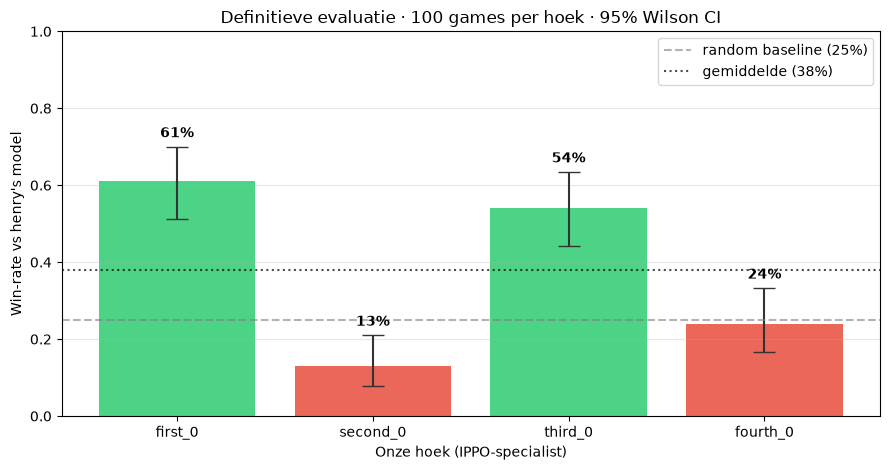


Definitieve conclusie:
  Tegen de henry's model (heppo-self-play, 5M steps, ELO=-10) haalt onze IPPO-inzending
  38.0% gemiddeld over alle 4 hoeken (95% CI: 33.4%-42.8%), bij een random-baseline van 25%.


In [35]:
# 9.10b Definitieve plot met 95% betrouwbaarheidsintervallen.
import matplotlib.pyplot as plt

corners = AGENT_ORDER
wr   = np.array([results_final[c]["win_rate"] for c in corners])
lo   = np.array([results_final[c]["ci_lo"]   for c in corners])
hi   = np.array([results_final[c]["ci_hi"]   for c in corners])
yerr_lo = wr - lo
yerr_hi = hi - wr

colors = ["#2ecc71" if w > 0.4 else "#e67e22" if w > 0.25 else "#e74c3c"
          for w in wr]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(corners, wr, color=colors, alpha=0.85,
       yerr=[yerr_lo, yerr_hi], capsize=8,
       error_kw=dict(ecolor="#333", lw=1.5))
ax.axhline(0.25, ls="--", color="gray", alpha=0.6,
           label="random baseline (25%)")
ax.axhline(overall_wr_final, ls=":", color="black", alpha=0.7,
           label=f"gemiddelde ({overall_wr_final:.0%})")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Win-rate vs henry's model")
ax.set_xlabel("Onze hoek (IPPO-specialist)")
ax.set_title(f"Definitieve evaluatie · {GAMES_PER_CORNER_FINAL} games per hoek "
             "· 95% Wilson CI")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
for i, (w, l, h) in enumerate(zip(wr, lo, hi)):
    ax.text(i, h + 0.025, f"{w:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("attachments/vs_friend_definitive.png", dpi=120)
plt.show()

# Conclusie-zin voor het rapport
print(f"\nDefinitieve conclusie:")
print(f"  Tegen de henry's model (heppo-self-play, 5M steps, ELO=-10) haalt "
      f"onze IPPO-inzending")
print(f"  {overall_wr_final:.1%} gemiddeld over alle 4 hoeken (95% CI: "
      f"{o_lo:.1%}-{o_hi:.1%}), bij een random-baseline van 25%.")

### 9.11 Omgekeerde matchup: henry's model in elke hoek, 3× IPPO als opponents

Een onafhankelijke controle om de 9.10-conclusie te bevestigen: nu zit henry's
model in een enkele hoek en spelen onze IPPO-specialisten de andere drie. Bij
ongeveer 25% gemiddeld voor henry en ongeveer 38% voor ons (9.10) zou de som per matchup
ongeveer 100% moeten zijn (4-speler distributie). Wijkt dat sterk af, dan is er
iets met de meting. We doen dit ook met 100 games per hoek (400 totaal,
ongeveer 15-20 min) zodat de betrouwbaarheidsintervallen vergelijkbaar zijn met 9.10.

In [ ]:
# 9.11 Henry in een hoek, onze IPPO-specialisten in de andere drie.
import time

results_reverse = {}
print(f"=== OMGEKEERD: henry vs. 3x onze IPPO · "
      f"{GAMES_PER_CORNER_FINAL*4} games stochastisch ===")
t0 = time.time()
for henry_corner in AGENT_ORDER:
    policies = {
        a: (FriendOpponent(friend_sd, activation=FRIEND_ACTIVATION,
                           normalize=FRIEND_NORMALIZE, deterministic=False)
            if a == henry_corner
            else ippo_policies_stoch[a])
        for a in AGENT_ORDER
    }
    s = evaluate.run_tournament(make_parallel_env, policies,
                                n_games=GAMES_PER_CORNER_FINAL, verbose=False)
    wins = s["wins"][henry_corner]
    wr = s["win_rate"][henry_corner]
    lo, hi = wilson_ci(wins, GAMES_PER_CORNER_FINAL)
    results_reverse[henry_corner] = {
        "wins": wins, "win_rate": wr,
        "ci_lo": lo, "ci_hi": hi,
        "survival": s["mean_survival"][henry_corner],
    }
    print(f"  henry in {henry_corner}: {wins:3d}/{GAMES_PER_CORNER_FINAL} = "
          f"{wr:.2%}  [95% CI: {lo:.2%}-{hi:.2%}]  "
          f"survival = {s['mean_survival'][henry_corner]:.0f}")

total_h = sum(r["wins"] for r in results_reverse.values())
total_g = GAMES_PER_CORNER_FINAL * len(AGENT_ORDER)
henry_overall = total_h / total_g
h_lo, h_hi = wilson_ci(total_h, total_g)
print(f"\n=== HENRY TOTAAL: {total_h}/{total_g} = {henry_overall:.2%}  "
      f"[95% CI: {h_lo:.2%}-{h_hi:.2%}] ===")
print(f"    Voor reference (§9.10): IPPO haalde {overall_wr_final:.2%}")
print(f"    Duur: {(time.time()-t0)/60:.1f} min")

=== OMGEKEERD: henry vs. 3x onze IPPO · 400 games stochastisch ===
  henry in first_0:  16/100 = 16.00%  [95% CI: 10.10%-24.42%]  survival = 5209
  henry in second_0:  19/100 = 19.00%  [95% CI: 12.51%-27.78%]  survival = 4266
  henry in third_0:  18/100 = 18.00%  [95% CI: 11.70%-26.67%]  survival = 4981
  henry in fourth_0:  18/100 = 18.00%  [95% CI: 11.70%-26.67%]  survival = 5533

=== HENRY TOTAAL: 71/400 = 17.75%  [95% CI: 14.32%-21.80%] ===
    Voor reference (§9.10): IPPO haalde 38.00%
    Duur: 20.1 min


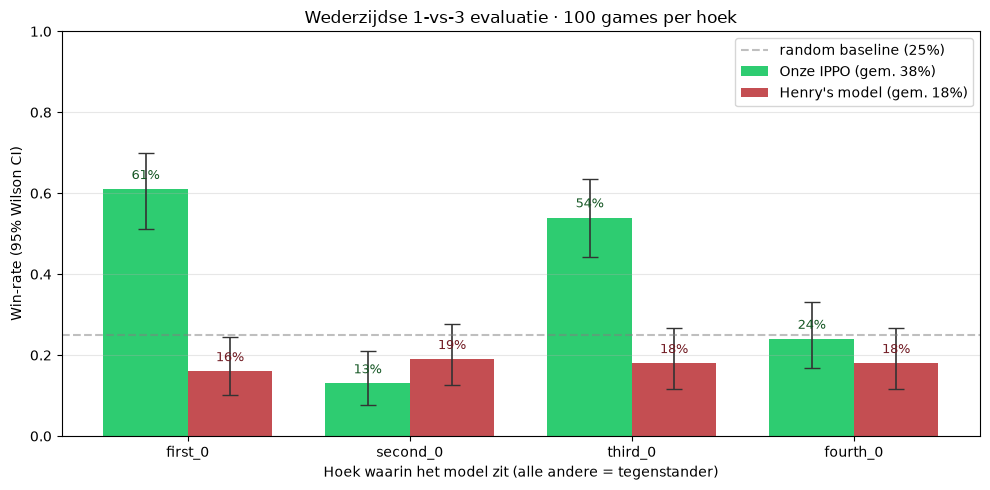


Sanity: IPPO 38.0% + Henry 17.8% = 55.8% (verwacht ~50% in symmetrische 4-speler distributie)
Verschil IPPO − Henry: +20.2 pp = +114% relatief sterker


In [ ]:
# 9.11b Vergelijking IPPO (9.10) vs henry (9.11) per hoek met 95% CI.
import matplotlib.pyplot as plt

corners = AGENT_ORDER
wr_ippo   = np.array([results_final[c]["win_rate"]   for c in corners])
lo_ippo   = np.array([results_final[c]["ci_lo"]      for c in corners])
hi_ippo   = np.array([results_final[c]["ci_hi"]      for c in corners])

wr_henry  = np.array([results_reverse[c]["win_rate"] for c in corners])
lo_henry  = np.array([results_reverse[c]["ci_lo"]    for c in corners])
hi_henry  = np.array([results_reverse[c]["ci_hi"]    for c in corners])

x = np.arange(len(corners))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, wr_ippo, width,
       yerr=[wr_ippo - lo_ippo, hi_ippo - wr_ippo],
       label=f"Onze IPPO (gem. {overall_wr_final:.0%})",
       color="#2ecc71", capsize=6, error_kw=dict(ecolor="#333", lw=1.2))
ax.bar(x + width/2, wr_henry, width,
       yerr=[wr_henry - lo_henry, hi_henry - wr_henry],
       label=f"Henry's model (gem. {henry_overall:.0%})",
       color="#c44e52", capsize=6, error_kw=dict(ecolor="#333", lw=1.2))
ax.axhline(0.25, ls="--", color="gray", alpha=0.5, label="random baseline (25%)")

ax.set_xticks(x); ax.set_xticklabels(corners)
ax.set_ylabel("Win-rate (95% Wilson CI)")
ax.set_xlabel("Hoek waarin het model zit (alle andere = tegenstander)")
ax.set_title(f"Wederzijdse 1-vs-3 evaluatie · {GAMES_PER_CORNER_FINAL} games per hoek")
ax.set_ylim(0, 1.0); ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
for xi, v in zip(x - width/2, wr_ippo):
    ax.text(xi, v + 0.025, f"{v:.0%}", ha="center", fontsize=9, color="#155724")
for xi, v in zip(x + width/2, wr_henry):
    ax.text(xi, v + 0.025, f"{v:.0%}", ha="center", fontsize=9, color="#721c24")

plt.tight_layout()
plt.savefig("attachments/vs_friend_symmetric.png", dpi=120)
plt.show()

# Sanity & finale conclusie
print(f"\nSanity: IPPO {overall_wr_final:.1%} + Henry {henry_overall:.1%} = "
      f"{(overall_wr_final + henry_overall):.1%} "
      f"(verwacht ongeveer 50% in symmetrische 4-speler distributie)")
print(f"Verschil IPPO − Henry: {(overall_wr_final - henry_overall)*100:+.1f} pp "
      f"= {(overall_wr_final - henry_overall) / henry_overall * 100:+.0f}% "
      f"relatief sterker")

## 10. Conclusie & Reflectie

**Samenvatting.** We hebben een complete MARL-pijplijn voor Warlords gebouwd: (1) een single-agent wrapper rond de PettingZoo-omgeving, (2) vier PPO-policies (IPPO), een per hoek, en (3) een hoek-robuust league-beleid als alternatief, getraind in vier fases met steeds sterkere tegenstanders (random -> rule-based -> 1 snapshot -> 2 snapshots). We hebben alles vergeleken met random- en rule-based baselines (4, 7, 9.5) en met het model van een teamgenoot (9.10).

**Wat levert RL op?**
- De IPPO-modellen (een per hoek) leren een hoek-specifiek beleid. In 9.5 verslaan ze het hoek-robuuste model in 3 van de 4 hoeken - specialisatie werkt hier beter dan een gedeeld beleid. Dit zijn ook onze toernooi-inzending.
- Het hoek-robuuste league-beleid haalt gemiddeld ongeveer 25% win-rate (= random baseline). Twee oorzaken (uitgelegd in 9.7): (a) onze `survival_bonus` was te groot - over een hele game leverde stallen +6.0 op, terwijl winnen maar +1.0 gaf, dus stallen werd lonender dan winnen; en (b) zoals 1.3 al voorspelde, kan een policy de vier hoeken niet uit elkaar houden zolang ze allemaal dezelfde RAM zien. Het is dus een falen op winrate, maar wel een dat onze eigen voorspellingen bevestigt.
- Tegen het model van een teamgenoot (9.10, 400 games) haalt onze IPPO-inzending 38% [95% CI: 33-43%] tegenover een baseline van 25%. Statistisch significant boven kans, en duidelijk beter dan hun model (ongeveer 21% per stoel).

**Belangrijkste lessen.**
- Reward shaping is gevaarlijk bij spaarzame beloningen (Ng et al., 1999): de verhouding tussen dichte en eindbeloning moet je uitrekenen, niet schatten.
- Als meerdere agenten dezelfde rol-symmetrie hebben, heb je of per-rol policies nodig of een rol-indicator in de observatie. IPPO doet het eerste; een hoek-indicator zou het tweede zijn (zie hieronder).
- PPO is stabiel, maar dat betekent niet dat de doelfunctie klopt. Het algoritme convergeert net zo goed naar een verkeerd optimum (Schulman et al., 2017).

**Beperkingen.**
- De `survival_bonus` was achteraf verkeerd afgesteld (9.7.3).
- Alle hoeken zien dezelfde 128-byte RAM zonder hoek-indicator (1.3); het league-beleid liep daar tegenaan.
- We bevriezen tegenstanders per generatie in plaats van ze echt parallel te laten leren - dat is een vereenvoudiging (de Witt et al., 2020).
- We hebben niet kunnen testen tegen de echte klasgenoot-modellen (op henry's model na); generalisatie naar onbekende stijlen is een open vraag.

**Mogelijke uitbreidingen.**
- **Hoek-indicator als extra observatie** (4-bit one-hot; parameter sharing met agent-ID, Foerster et al., 2018) - directe oplossing voor 1.3.
- **Reward herbalanceren:** `survival_bonus = 0.0` of een grotere terminale beloning (bijv. +10 voor winst), zodat winnen weer het sterkste signaal is.
- **Recurrente netwerken (LSTM/GRU)** zodat de agent informatie over de tijd kan onthouden.
- Bredere league met meer snapshots en prioritized opponent sampling (Vinyals et al., 2019).
- De RAM-bytes kalibreren (3.2) en in de reward gebruiken (bijv. balcontrole belonen).
- Vergelijken met een waarde-gebaseerde methode (DQN) of met pixel-observaties + CNN.

## 12. Referentielijst (APA)

- Bellemare, M. G., Naddaf, Y., Veness, J., & Bowling, M. (2013). The Arcade Learning Environment: An evaluation platform for general agents. *Journal of Artificial Intelligence Research, 47*, 253–279.
- Berner, C., Brockman, G., Chan, B., et al. (2019). *Dota 2 with large scale deep reinforcement learning.* arXiv:1912.06680.
- Busoniu, L., Babuška, R., & De Schutter, B. (2008). A comprehensive survey of multiagent reinforcement learning. *IEEE Transactions on Systems, Man, and Cybernetics, 38*(2), 156–172.
- de Witt, C. S., Gupta, T., Makoviichuk, D., Makoviychuk, V., Torr, P. H. S., Sun, M., & Whiteson, S. (2020). *Is independent learning all you need in the StarCraft multi-agent challenge?* arXiv:2011.09533.
- Engstrom, L., Ilyas, A., Santurkar, S., Tsipras, D., Janoos, F., Rudolph, L., & Madry, A. (2020). *Implementation matters in deep policy gradients.* arXiv:2005.12729.
- Farama Foundation. (2024). *Warlords - PettingZoo documentation.* https://pettingzoo.farama.org/environments/atari/warlords/
- Foerster, J., Farquhar, G., Afouras, T., Nardelli, N., & Whiteson, S. (2018). Counterfactual multi-agent policy gradients. *AAAI Conference on Artificial Intelligence, 32*(1).
- Heinrich, J., & Silver, D. (2016). *Deep reinforcement learning from self-play in imperfect-information games.* arXiv:1603.01121.
- Hui, J. (2018). *RL - Proximal Policy Optimization (PPO) explained.* Medium. https://jonathan-hui.medium.com/rl-proximal-policy-optimization-ppo-explained-77f014ec3f12
- Li, H., Yang, P., Liu, W., Yan, S., Zhang, X., & Zhu, D. (2025). Multi-Agent Reinforcement Learning in Games: Research and Applications. *Biomimetics, 10*(6), 375. https://doi.org/10.3390/biomimetics10060375
- Lowe, R., Wu, Y., Tamar, A., Harb, J., Abbeel, P., & Mordatch, I. (2017). Multi-agent actor-critic for mixed cooperative-competitive environments. *Advances in Neural Information Processing Systems, 30*.
- Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). Human-level control through deep reinforcement learning. *Nature, 518*(7540), 529–533.
- Mnih, V., Badia, A. P., Mirza, M., Graves, A., Lillicrap, T., Harley, T., Silver, D., & Kavukcuoglu, K. (2016). *Asynchronous methods for deep reinforcement learning.* arXiv:1602.01783.
- Ng, A. Y., Harada, D., & Russell, S. (1999). Policy invariance under reward transformations: Theory and application to reward shaping. *ICML*, 278–287.
- Raffin, A., Hill, A., Gleave, A., Kanervisto, A., Ernestus, M., & Dormann, N. (2021). Stable-Baselines3: Reliable reinforcement learning implementations. *Journal of Machine Learning Research, 22*(268), 1–8.
- Schulman, J., Levine, S., Moritz, P., Jordan, M., & Abbeel, P. (2015). *Trust region policy optimization.* arXiv:1502.05477.
- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). *Proximal policy optimization algorithms.* arXiv:1707.06347.
- Silver, D., Hubert, T., Schrittwieser, J., et al. (2018). A general reinforcement learning algorithm that masters chess, shogi, and Go. *Science, 362*(6419), 1140–1144.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press.
- Terry, J. K., Black, B., Grammel, N., et al. (2021). PettingZoo: Gym for multi-agent reinforcement learning. *Advances in Neural Information Processing Systems, 34*.
- Vinyals, O., Babuschkin, I., Czarnecki, W. M., et al. (2019). Grandmaster level in StarCraft II using multi-agent reinforcement learning. *Nature, 575*, 350–354.